## Дисклеймер!!!!!

Поскольку я терпеть ненавижу отвратно структурированный код, я большую часть инжиринга признаков вынес в отдельный файл. Направление действий будет видно как и указано в задании, но сразу для всего. Я не писал всё одним батчем, тут положена куча коммитов, просто для сохранения ясности я решил не сваливать всё в одну нечитабельную кучу. 

## Грузим данные

In [1]:
from data_preparation import OzonDataFormer
from datetime import date

In [2]:
former = OzonDataFormer()

In [3]:
former.fit_text_vectorizer(feature_end_date=date(2024, 5, 31))

In [4]:
train_df = former.construct_dataset(
    feature_end_date=date(2024, 5, 31),
    target_start_date=date(2024, 6, 1),
    target_end_date=date(2024, 6, 30),
)

In [5]:
val_df = former.construct_dataset(
    feature_end_date=date(2024, 6, 30),
    target_start_date=date(2024, 7, 1),
    target_end_date=date(2024, 7, 31),
)

In [6]:
train_df = train_df.to_pandas()
X_train = train_df.drop(columns=['user_id', 'target']).sort_index(axis=1)
y_train = train_df['target']

In [7]:
val_df = val_df.to_pandas()
X_val = val_df.drop(columns=['user_id', 'target']).sort_index(axis=1)
y_val = val_df['target']

## Проверка адекватности разделения на тренировку и валидацию

In [8]:
cat_features = list(X_train.select_dtypes('category').columns) + list(X_train.select_dtypes('object').columns)

In [9]:
from catboost.utils import get_gpu_device_count

if get_gpu_device_count() > 0:
    task_type = 'GPU'
else:
    task_type = 'CPU'

params = {
    'iterations': 100,
    'depth': 7,
    'learning_rate': 0.05,
    'random_state': 1,
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'auto_class_weights': 'Balanced',
    'task_type': task_type,
    'cat_features': cat_features
}

In [10]:
from validation_check import get_train_val_difference

diff_score, _, _ = get_train_val_difference(X_train, y_train, X_val, y_val, params)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7976329	best: 0.7976329 (0)	total: 70ms	remaining: 6.93s
10:	test: 0.8086791	best: 0.8086791 (10)	total: 508ms	remaining: 4.11s
20:	test: 0.8110446	best: 0.8110446 (20)	total: 950ms	remaining: 3.57s
30:	test: 0.8119568	best: 0.8119568 (30)	total: 1.39s	remaining: 3.1s
40:	test: 0.8127510	best: 0.8127510 (40)	total: 1.84s	remaining: 2.65s
50:	test: 0.8131504	best: 0.8131504 (50)	total: 2.29s	remaining: 2.2s
60:	test: 0.8136815	best: 0.8136815 (60)	total: 2.73s	remaining: 1.75s
70:	test: 0.8139256	best: 0.8139256 (70)	total: 3.18s	remaining: 1.3s
80:	test: 0.8141689	best: 0.8141689 (80)	total: 3.62s	remaining: 848ms
90:	test: 0.8144501	best: 0.8144501 (90)	total: 4.06s	remaining: 401ms
99:	test: 0.8146168	best: 0.8146168 (99)	total: 4.46s	remaining: 0us
bestTest = 0.8146167994
bestIteration = 99


In [11]:
diff_score

0.7101643569865146

Ну выглядит вроде адекватно учитывая что в данных очевидно есть временная зависимость

## Обучение модели

In [12]:
from catboost import CatBoostClassifier, Pool

In [13]:
train_pool = Pool(X_train, label=y_train, cat_features=cat_features)

val_pool = Pool(X_val, label=y_val, cat_features=cat_features)

In [14]:
params['iterations'] = 5000

model = CatBoostClassifier(**params)

In [ ]:
try:
    model.load_model('models/weird_shiet.bin')
except Exception:
    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=10,
        early_stopping_rounds=50,
    )

In [ ]:
model.save_model("models/weird_shiet.bin")

In [17]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

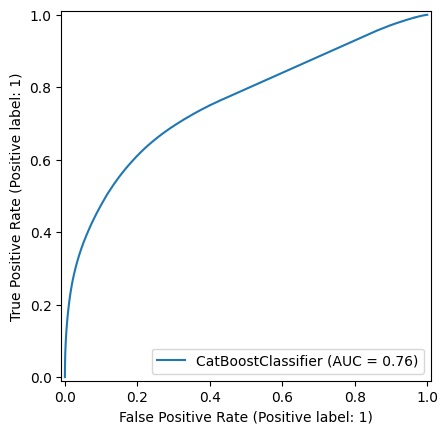

In [18]:
RocCurveDisplay.from_estimator(model, X_val, y_val)

## Интерпретация модели

In [19]:
from utils2 import AutoFeatureStandardizer, BinaryClassifierInterpreter
from cluster_compare import NotebookBinaryClusterInterpreter

In [20]:
import panel as pn
pn.extension()

In [35]:
tool = NotebookBinaryClusterInterpreter(
    X=X_train.loc[::10],
    # y=y_train.loc[::10],
)

/home/i3alumba/Projects/AI/aim_ml/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/i3alumba/Projects/AI/aim_ml/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/i3alumba/Projects/AI/aim_ml/.venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


In [36]:
tool.show()

BokehModel(combine_events=True, render_bundle={'docs_json': {'2ff7b628-e332-4309-89ff-eab1c7f6b118': {'version…

А выглядит интересно, чётко видны 2 кластера, и это без переданной разметки. Надо посмотреть чё там такое

In [23]:
interpreter = BinaryClassifierInterpreter(
    train=(X_train[::10], y_train[::10]),
    val=(X_val[::10], y_val[::10]),
    model=model
)

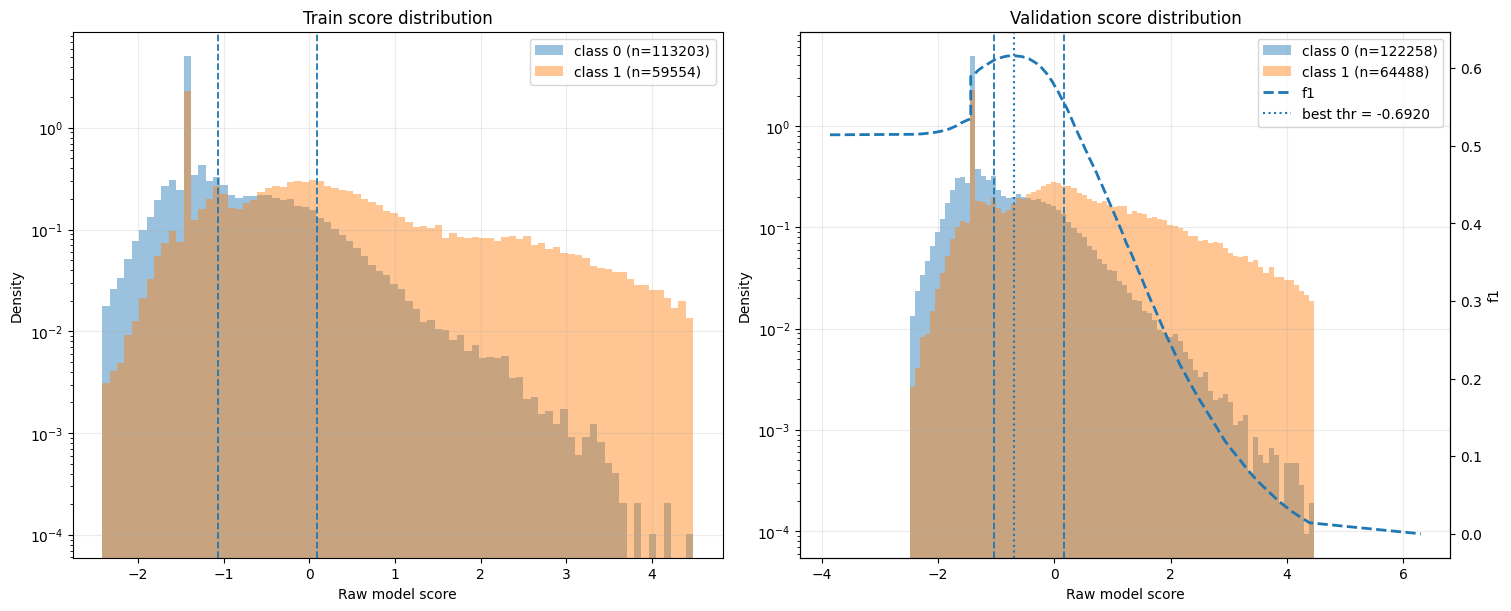

In [24]:
interpreter.plot_score_histograms_with_val_metric(val_metric_name="f1", use_log_density_y=True);

In [25]:
interpreter.plot_float_feature_histograms()

In [26]:
interpreter.plot_score_feature_contours()

In [27]:
test_df = former.construct_dataset(
    feature_end_date=date(2024, 7, 31),
    users_df=former.test_users_submission,
)

In [28]:
test_df = test_df.to_pandas().sort_index(axis=1)

In [30]:
predict = model.predict(test_df.drop(columns='user_id'), prediction_type='RawFormulaVal')

In [31]:
from scipy.special import expit

In [32]:
probs = expit(predict)

In [33]:
import pandas as pd
import polars as pl

In [34]:
test_df['predict'] = probs
test_df[['user_id', 'predict']].to_csv('overfitted_ahh.csv', index=False)